Purpose: prepare for deployment.

Expected contents:

load saved best model
run single-image prediction
top-k predictions
optional low-confidence handling
package outputs for app/API

This is your “can I serve this cleanly?” notebook.

In [ ]:
import os
import re
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from beakspeak.data import load_metadata, split_data, create_dataset

# --- Paths ---
DATA_DIR = Path.cwd().parent / "data"
MODEL_DIR = Path.cwd().parent / "models"

In [5]:
metadata_df = load_metadata(DATA_DIR)

metadata_df.head()

,image_id,image_path,class_id,class_name,is_training_image,file_path,split
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,0,/Users/keira/Documents/projects/beakspeak/data...,test
1,2,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,1,/Users/keira/Documents/projects/beakspeak/data...,train
2,3,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,0,/Users/keira/Documents/projects/beakspeak/data...,test
3,4,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,1,/Users/keira/Documents/projects/beakspeak/data...,train
4,5,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,1,/Users/keira/Documents/projects/beakspeak/data...,train


In [5]:
# Create class_id to class_name mapping
class_map = (
    metadata_df[["class_id", "class_name"]]
    .drop_duplicates()
    .sort_values("class_id")
)

# Clean labels for display
def clean_class_name(name):
    name = name.split(".", 1)[-1]  # Remove prefix
    name = name.replace("_", " ")  # Swap underscores for spaces
    return name

class_id_to_name = {
    class_id - 1: clean_class_name(name)
    for class_id, name in zip(class_map["class_id"], class_map["class_name"])
}

# Checks
print(class_id_to_name[0])
print(class_id_to_name[199])


Black footed Albatross
Common Yellowthroat


## Confidence threshold tuning

The app always returns a prediction, even when the image is unclear or not a bird. To make the interface more honest, this section uses the validation set to choose a simple confidence threshold for flagging low-confidence predictions.

In [ ]:
# ---- Create validation dataset ----

# Load model
MODEL_PATH = MODEL_DIR / "efficientnetb0_fine_tuned.keras"
model = tf.keras.models.load_model(MODEL_PATH)

train_df, val_df, test_df = split_data(metadata_df)

# Prepare labels for tf
train_df["label"] = train_df["class_id"] - 1
val_df["label"] = val_df["class_id"] - 1
test_df["label"] = test_df["class_id"] - 1

# Create train, test, val datasets
train_ds = create_dataset(train_df, shuffle=True, scaling=False)
val_ds = create_dataset(val_df, shuffle=False, scaling=False)
test_ds = create_dataset(test_df, shuffle=False, scaling=False)

In [9]:
# Get true labels for validation set
y_val_true = np.concatenate([y for x, y in val_ds], axis=0)

# Get predictions for validation set
val_pred_raw = model.predict(val_ds)
val_pred_probs = tf.nn.softmax(val_pred_raw, axis=1).numpy()

# Top 1 class predictions (index of highest probability)
y_val_pred = np.argmax(val_pred_probs, axis=1)

# Top 1 confidence scores (highest probability)
y_val_confidence = np.max(val_pred_probs, axis=1)

# Correct or not correct predictions
val_correct = (y_val_pred == y_val_true)

# Convert to DataFrame for analysis
threshold_df = pd.DataFrame({
    "true_label": y_val_true,
    "pred_label": y_val_pred,
    "top1_confidence": y_val_confidence,
    "correct": val_correct
})

threshold_df.head()

38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 285ms/step


,true_label,pred_label,top1_confidence,correct
0,62,62,0.996947,True
1,37,37,0.567201,True
2,7,24,0.304289,False
3,125,125,0.459788,True
4,108,108,0.989161,True


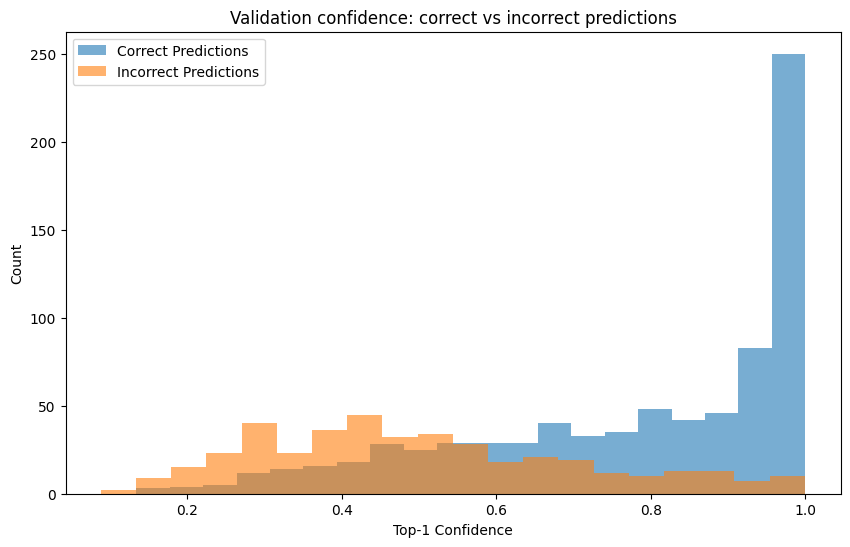

In [10]:
plt.figure(figsize=(10, 6))

plt.hist(
    threshold_df.loc[threshold_df["correct"], "top1_confidence"],
    bins=20,
    alpha=0.6,
    label="Correct Predictions"
)

plt.hist(
    threshold_df.loc[~threshold_df["correct"], "top1_confidence"],
    bins=20,
    alpha=0.6,
    label="Incorrect Predictions"
)

plt.xlabel("Top-1 Confidence")
plt.ylabel("Count")
plt.title("Validation confidence: correct vs incorrect predictions")
plt.legend()
plt.show()

In [ ]:
candidate_thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

rows = []

for threshold in candidate_thresholds:
    low_conf = threshold_df["top1_confidence"] < threshold

    # Of the predictions below threshold, how many are actually wrong?
    if low_conf.sum() > 0:
        pct_flagged_that_are_wrong = (~threshold_df.loc[low_conf, "correct"]).mean()
    else:
        pct_flagged_that_are_wrong = np.nan

    # Of all wrong predictions, how many would we catch?
    pct_wrong_caught = low_conf[~threshold_df["correct"]].mean()

    # Of all correct predictions, how many would we also hide / flag?
    pct_correct_flagged = low_conf[threshold_df["correct"]].mean()

    rows.append({
        "threshold": threshold,
        "flag_quality": pct_flagged_that_are_wrong,
        "coverage": pct_wrong_caught,
        "cost": pct_correct_flagged
    })

threshold_results = pd.DataFrame(rows)
threshold_results

# flag_quality = % low-confidence that are actually mistakes
# coverage = % of mistakes flagged
# cost = % of correct predictions flagged

,threshold,flag_quality,coverage,cost
0,0.30,0.765306,0.182927,0.029151
1,0.40,0.707071,0.341463,0.073511
2,0.50,0.674556,0.556098,0.139417
3,0.55,0.647783,0.641463,0.181242
4,0.60,0.612766,0.702439,0.230672
5,0.70,0.568761,0.817073,0.321926
6,0.80,0.521490,0.887805,0.423321
7,0.90,0.468263,0.953659,0.562738


In [15]:
candidate_thresholds = [0.5, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.57, 0.58, 0.59, 0.6]

rows = []

for threshold in candidate_thresholds:
    low_conf = threshold_df["top1_confidence"] < threshold

    # Of the predictions below threshold, how many are actually wrong?
    if low_conf.sum() > 0:
        pct_flagged_that_are_wrong = (~threshold_df.loc[low_conf, "correct"]).mean()
    else:
        pct_flagged_that_are_wrong = np.nan

    # Of all wrong predictions, how many would we catch?
    pct_wrong_caught = low_conf[~threshold_df["correct"]].mean()

    # Of all correct predictions, how many would we also hide / flag?
    pct_correct_flagged = low_conf[threshold_df["correct"]].mean()

    rows.append({
        "threshold": threshold,
        "flag_quality": pct_flagged_that_are_wrong,
        "coverage": pct_wrong_caught,
        "cost": pct_correct_flagged
    })

threshold_results = pd.DataFrame(rows)
threshold_results

# flag_quality = % low-confidence that are actually mistakes
# coverage = % of mistakes flagged
# cost = % of correct predictions flagged

,threshold,flag_quality,coverage,cost
0,0.50,0.674556,0.556098,0.139417
1,0.51,0.669492,0.578049,0.148289
2,0.52,0.662125,0.592683,0.157161
3,0.53,0.665789,0.617073,0.160963
4,0.54,0.662371,0.626829,0.166033
5,0.55,0.647783,0.641463,0.181242
6,0.56,0.643541,0.656098,0.188847
7,0.57,0.637850,0.665854,0.196451
8,0.58,0.634091,0.680488,0.204056
9,0.59,0.625272,0.700000,0.217997


We choose a threshold that catches a meaningful proportion of low-quality predictions, while avoiding flagging too many high-quality ones.

👉 **A confidence threshold of ~0.53 was selected** based on validation performance, balancing the ability to flag low-quality predictions (~62% coverage) while limiting unnecessary warnings on correct predictions (~16%).

## Exporting species names

For use in URL and display name exceptions in UI.

In [ ]:
class_map = (
    metadata_df[["class_id", "class_name"]]
    .drop_duplicates()
    .sort_values("class_id")
)

def clean_name(name):
    # remove numeric prefix like "001."
    name = re.sub(r"^\d+\.", "", name)
    # replace underscores with spaces
    name = name.replace("_", " ")
    # tidy whitespace
    name = re.sub(r"\s+", " ", name).strip()
    return name.title()

class_id_to_name = {
    class_id - 1: clean_name(name)
    for class_id, name in zip(class_map["class_id"], class_map["class_name"])
}

species_df = pd.DataFrame(
    sorted(class_id_to_name.values()),
    columns=["species"]
)

species_df.to_csv("species_list.csv", index=False)